# Day 23 Membandingkan Model Regresi : Linear vs KNN vs Decision Tree



Tidak ada satu model yang selalu terbaik. Di notebook ini saya melatih **tiga
algoritma regresi berbeda** pada data harga rumah Boston, lalu membandingkannya
secara adil memakai metrik yang sama.

> 🎯 **Tujuan Pembelajaran**
> - Melatih **Linear Regression**, **KNN Regressor**, dan **Decision Tree Regressor**.
> - Membandingkan model dengan **R² & RMSE** pada data uji yang sama.
> - Memahami pentingnya **standardisasi** untuk KNN.
> - Mengenal konsep **bias–variance** secara ringan.

## Tentang Dataset

## 📊 Tentang Dataset

**Boston Housing** — data harga rumah di kota Boston beserta atribut lingkungannya.

- **Sumber:** [Kaggle — fedesoriano/the-boston-houseprice-data](https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data)
- **Jumlah data:** 506 baris × 14 kolom

| Kolom | Arti |
|-------|------|
| `RM` | Rata-rata jumlah kamar per rumah |
| `LSTAT` | % penduduk berstatus ekonomi rendah |
| `PTRATIO` | Rasio murid : guru |
| `CRIM` | Tingkat kriminalitas |
| `NOX` | Konsentrasi polusi (NOx) |
| `MEDV` | **Harga median rumah (ribuan USD) — target** |

(Kolom lain: ZN, INDUS, CHAS, AGE, DIS, RAD, TAX, B.)

## Import Library

- **scikit-learn** → tiga model regresi + `StandardScaler` + metrik.
- **pandas/numpy/seaborn/matplotlib** → olah data & visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Import Dataset

In [3]:
!pip install kaggle

!kaggle datasets download -d fedesoriano/the-boston-houseprice-data

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
License(s): copyright-authors
100% 12.3k/12.3k [00:00<00:00, 27.4MB/s]



In [4]:
!unzip the-boston-houseprice-data.zip

Archive:  the-boston-houseprice-data.zip
  inflating: boston.csv              


## Eksplorasi Awal Dataset

In [6]:
df = pd.read_csv('boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [9]:
df.isnull().sum().sum()

np.int64(0)

Interpretasi:
- Semua kolom numerik, `MEDV` harga rata rata adalah target
- 506 baris, 14 kolom numerik, tanpa nilai yang hilang
- Harga rumah (`MEDV`) berkisar 5–50 ribu USD. Skala antar fitur sangat berbeda (mis. `TAX` ratusan, `NOX` < 1) — ini alasan KNN butuh standardisasi.
- Tidak ada missing value

## Exploratori Data dan Visualisasi

Tiga grafik untuk memahami hubungan fitur dengan harga.

### a) Heatmap Kolerasi

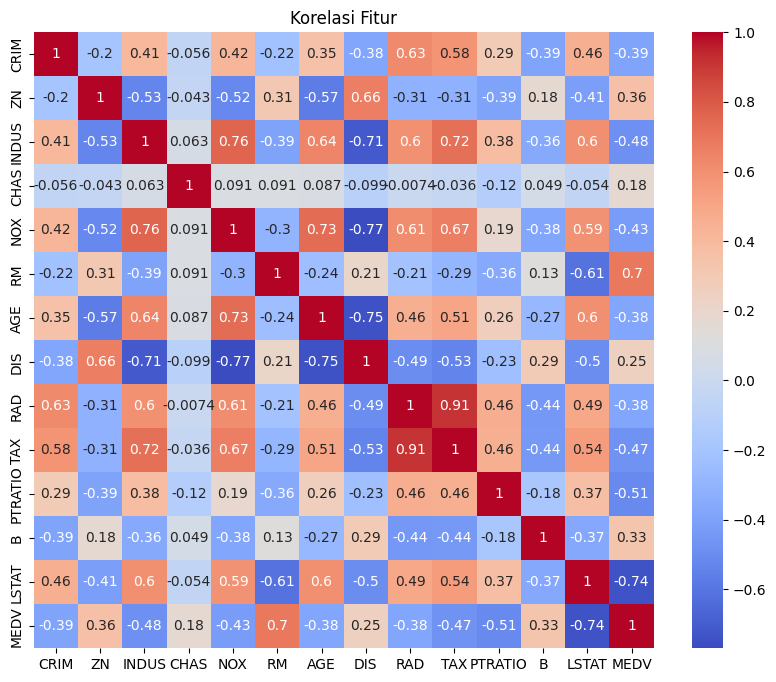

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

Interpretasi:
- `RM` mempunyain korelasi positif kuat dengan `MEDV`
- `LSTAT`(status ekonomi rendah) mempunyai kolerasi negatif kuat dengan `MEDV`,

### b) RM vs MEDV ( ScatterPlot )

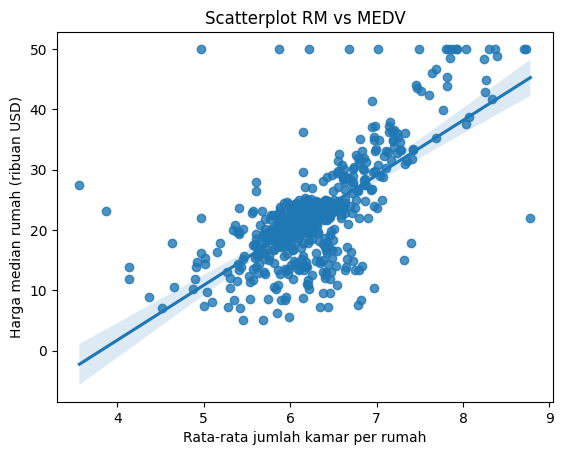

In [11]:
sns.regplot(data=df, x='RM', y='MEDV')
plt.title('Scatterplot RM vs MEDV')
plt.xlabel('Rata-rata jumlah kamar per rumah')
plt.ylabel('Harga median rumah (ribuan USD)')
plt.show()

Interpretasi:
- Terdapat korelasi positif yang kuat antara jumlah kamar (RM) dan harga rumah (MEDV). Semakin banyak rata-rata jumlah kamar pada suatu rumah (RM), semakin tinggi pula harga median rumah tersebut (MEDV)
- Garis biru di tengah menunjukkan tren linier secara keseluruhan. Kita bisa melihat bahwa saat jumlah kamar berada di kisaran 6, harga median rumah umumnya berada di sekitar angka 20 hingga 25 (ribu USD atau $20.000 - $25.000 tergantung skala dataset aslinya). Ketika jumlah kamar mendekati 8 atau lebih, harga median rumah melonjak naik hingga mendekati angka maksimum 50.

### c) LSTAT vs MEDV ( ScatterPlot )

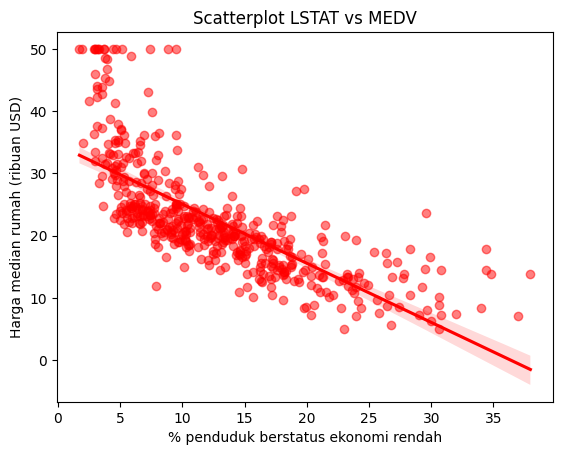

In [13]:
sns.regplot(data=df, x='LSTAT',
            y='MEDV',
            scatter_kws={"alpha":0.5},
            color='red')
plt.title('Scatterplot LSTAT vs MEDV')
plt.xlabel('% penduduk berstatus ekonomi rendah')
plt.ylabel('Harga median rumah (ribuan USD)')
plt.show()

Interpretasi:
- Terdapat korelasi negatif yang kuat antara kedua variabel ini. Semakin tinggi persentase penduduk berstatus ekonomi rendah di suatu kawasan (LSTAT), maka harga median rumah di kawasan tersebut (MEDV) cenderung semakin murah/rendah.
- Area Kiri (LSTAT Rendah): Ketika persentase penduduk berstatus ekonomi rendah kecil (di bawah 10%), harga rumah bervariasi dari sedang hingga sangat tinggi (banyak yang menyentuh batas maksimum di angka 50).   
- Area Kanan (LSTAT Tinggi): Ketika persentase LSTAT meningkat di atas 20%, harga rumah terkonsentrasi di angka yang jauh lebih rendah, mayoritas berada di bawah 20 ribu USD.


- Jika diperhatikan lebih seksama, sebaran titik-titik merah tidak sepenuhnya membentuk garis lurus, melainkan sedikit melengkung (kurva monotonik).

- Dalam praktik Machine Learning, fitur seperti LSTAT seringkali di-transformasi menggunakan fungsi logaritmik (log-transform) agar hubungannya dengan variabel target menjadi benar-benar linier, sehingga performa Linear Regression bisa meningkat.

## Preprocessing - Split & Standarisasi


- Bagi data 80/20.
- Lalu **standardisasi** fitur (rata-rata 0, std 1).

Ini krusial untuk **KNN** yang mengukur jarak antar titik — tanpa scaling, fitur berskala besar (seperti TAX) akan mendominasi perhitungan jarak.

In [14]:
X = df.drop(columns='MEDV')
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))
print("train:", X_train_scaled.shape)
print("test:", X_test_scaled.shape)

[-2.63815372e-17  0.00000000e+00 -4.17707673e-17  1.31907686e-17
 -5.11142284e-16 -2.61616911e-16 -4.85859977e-16  5.24882668e-17
 -9.45338417e-17 -1.51693839e-16  8.51903806e-16 -4.94653823e-16
 -1.79174607e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
train: (404, 13)
test: (102, 13)


Informasi Penting sebelum  `fit_transform`

🔑 **Anti-bocor (penting!):**
  
  - perhatikan polanya — `fit_transform` di **data latih**, lalu

  - `transform` saja di **data uji**. Kalau scaler di-`fit` pada seluruh data *sebelum* split,

  -   informasi data uji "bocor" ke pelatihan dan skor jadi terlalu optimistis.
  - Pola ini berlaku untuk semua langkah preprocessing yang "belajar" dari data (scaling, imputasi, encoding).

## Modeling - LR , KNN , DT


In [16]:
def train(model, X_tr, X_ts):
    model.fit(X_tr, y_train)
    return model.predict(X_ts)

In [18]:
y_pred_lin = train(LinearRegression(), X_train, X_test)
y_pred_knn = train(KNeighborsRegressor(n_neighbors=5), X_train_scaled, X_test_scaled)
y_pred_tree = train(DecisionTreeRegressor(random_state=42, max_depth=5) , X_train, X_test)

In [19]:
def skor_regresi(y_true, y_pred) -> dict:
    """Hitung R², MAE, RMSE sekaligus & kembalikan sebagai dict.

    RMSE dihitung sebagai akar dari MSE (tanpa argumen `squared=`) agar kompatibel
    di semua versi scikit-learn.
    """
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
    }


def tabel_metrik(hasil: dict, desimal: int = 3) -> pd.DataFrame:
    """Bandingkan beberapa model dalam satu tabel R²/MAE/RMSE.

    Parameters
    ----------
    hasil : dict
        Pemetaan ``{nama_model: (y_true, y_pred)}``.
    desimal : int, default 3
        Pembulatan angka.

    Returns
    -------
    pd.DataFrame
        Baris = model, kolom = R2, MAE, RMSE. Jauh lebih rapi daripada
        menyebar banyak ``print()``.
    """
    baris = {nama: skor_regresi(yt, yp) for nama, (yt, yp) in hasil.items()}
    return pd.DataFrame(baris).T[["R2", "MAE", "RMSE"]].round(desimal)

In [20]:
tabel = tabel_metrik({"LR": (y_test, y_pred_lin),
                       "KNN": (y_test, y_pred_knn),
                       "DT": (y_test, y_pred_tree)})
tabel

,R2,MAE,RMSE
LR,0.669,3.189,4.929
KNN,0.719,2.592,4.539
DT,0.883,2.308,2.925


Penjelasan Metrik Evaluasi
- $R^2$ (R-Squared): Menunjukkan seberapa besar variasi target (harga rumah) yang dapat dijelaskan oleh model. Nilai mendekati 1.0 berarti model sangat baik.
- MAE (Mean Absolute Error): Rata-rata selisih absolut antara nilai prediksi dan aktual. Semakin kecil nilainya, semakin akurat model secara rata-rata.
- RMSE (Root Mean Squared Error): Mirip dengan MAE, tetapi memberikan penalti lebih besar pada error yang tinggi (outlier).

Interpretasi:
- Decision Tree (DT) - Model Terbaik:
  - Model ini mendominasi di semua metrik dengan nilai $R^2$ tertinggi yaitu 0.883 (mampu menjelaskan sekitar 88.3% variasi data).
  - Nilai error-nya juga paling kecil, yaitu MAE 2.308 dan RMSE 2.925. Hal ini menunjukkan bahwa Decision Tree mampu menangkap pola non-linear dan kompleks pada data perumahan jauh lebih baik dibanding dua model lainnya.

- K-Nearest Neighbors (KNN):
  - Berada di posisi kedua dengan $R^2$ sebesar 0.719 (menjelaskan sekitar 71.9% variasi).Memiliki MAE 2.592 dan RMSE 4.539.
  - Perhatikan bahwa selisih antara RMSE dan MAE pada KNN cukup besar, yang menandakan ada beberapa prediksi meleset cukup jauh (sensitif terhadap outlier).

- Linear Regression (LR) -
  - Model Paling Lemah:Memiliki performa paling rendah di antara ketiganya dengan $R^2$ paling kecil yaitu 0.669 dan error tertinggi (MAE 3.189, RMSE 4.925).
  - Hal ini wajar karena Linear Regression berasumsi bahwa hubungan antar fitur bersifat linier murni, sementara data harga rumah (seperti Boston Housing) seringkali memiliki hubungan non-linear yang lebih kompleks yang bisa diatasi dengan baik oleh model berbasis pohon seperti Decision Tree.

## Evaluasi & Perbandingan Algoritma

### Grafik Perbandingan RMSE vs R2

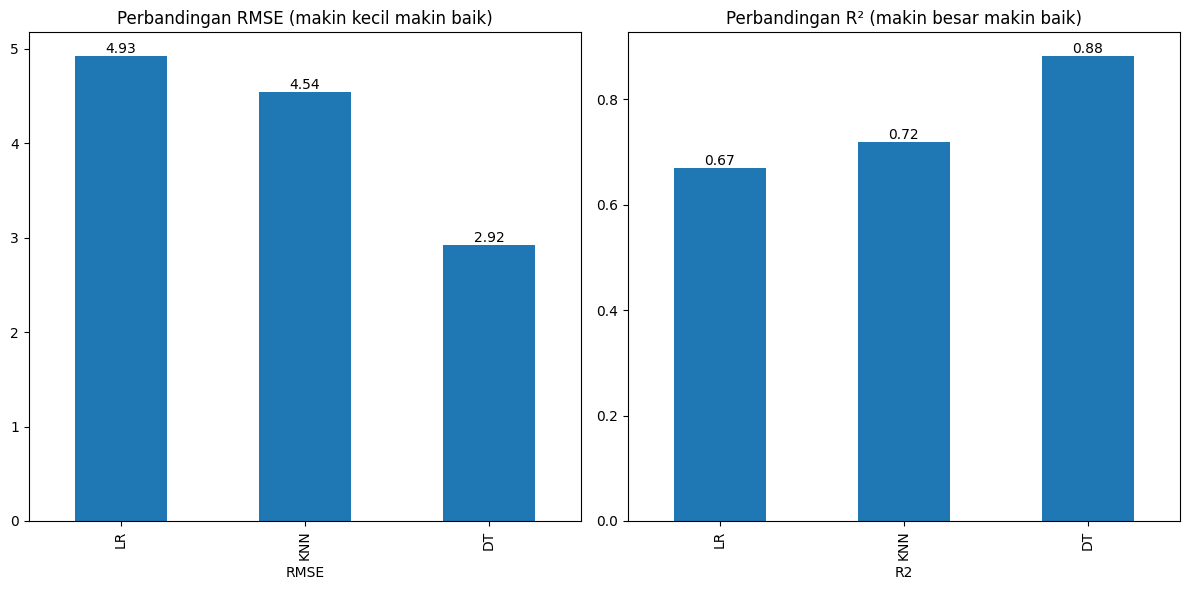

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

tabel['RMSE'].plot(kind='bar', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')
axes[0].set_title('Perbandingan RMSE (makin kecil makin baik)')
axes[0].set_xlabel('RMSE')

tabel['R2'].plot(kind='bar', ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')
axes[1].set_title('Perbandingan R² (makin besar makin baik)')
axes[1].set_xlabel('R2')

plt.tight_layout()
plt.show()

Interpretasi:
- Model terbaik saat ini adalah Decission Tree dengan R2 Paling tinggi dan RMSE paling rendah

### Prediksi vs Aktual

In [28]:
best_mod = tabel['RMSE'].idxmin()
pred_map = {"Linear": y_pred_lin, "KNN": y_pred_knn, "DT": y_pred_tree}
y_pred_best = pred_map[best_mod]

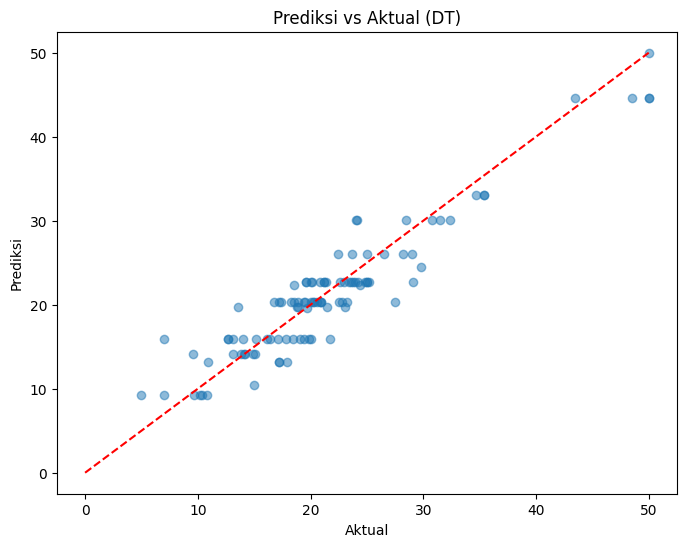

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([0, 50], [0, 50], color='red', linestyle='--')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.title(f'Prediksi vs Aktual ({best_mod})')
plt.show()

Interpretasi:
-  Titik mengelompok di sekitar garis merah → prediksi model
terbaik cukup akurat. Penyimpangan terbesar biasanya terjadi pada rumah termahal
(harga di-*cap* 50, sehingga model sulit menebak nilai sebenarnya).

In [30]:
print("Model terbaik berdasar RMSE:", best_mod)

Model terbaik berdasar RMSE: DT


## Kesimpulan dan Insight



- **Linear Regression**: sederhana & cepat, tapi **bias tinggi** — gagal menangkap
  hubungan non-linear, jadi R² lebih rendah.
- **KNN**: fleksibel, tapi **wajib distandardisasi** agar adil; sensitif terhadap nilai `k`.
- **Decision Tree**: menangkap pola non-linear, tapi **variance tinggi** — mudah
  overfit bila `max_depth` tidak dibatasi.
- **Insight:** untuk data ini, model non-linear (KNN/Tree) umumnya lebih akurat,
  menunjukkan harga rumah dipengaruhi interaksi fitur yang kompleks. Memilih model
  selalu soal **trade-off** antara kesederhanaan dan akurasi.
